# Does the Conservative Formula Still Work?
## Replication design and extensions of a simple equity strategy
**MTH 9897 · Project 8 · First draft · September 29, 2026**  
**Team / authors:** [Add names and team number]

> **Draft status: executable research prototype, not an empirical replication.**
> The saved outputs use seeded, synthetic stock data. No WRDS equity extract was available for this draft.
> The existing course CSVs in the workspace contain corporate bonds and are not used here.
> Every chart and results table is labeled accordingly. Do not describe these outputs as evidence that the strategy works.

**Primary paper:** Pim van Vliet and David Blitz (2018), *The Conservative Formula: Quantitative Investing Made Easy*,
[March working paper, SSRN 3145152](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3145152).
The published version lists David Blitz and Pim van Vliet, *The Journal of Portfolio Management*, 44(7).

### Abstract
This project asks whether combining low volatility, momentum, and shareholder payouts produces a useful equity selection rule.
The intended study will replicate a quarterly strategy in US stocks using historical CRSP data, then evaluate recent-period
performance, the incremental contribution of each signal, and sensitivity to trading costs. This first draft specifies the data
contract and research design and implements the selection and portfolio accounting in Python. A synthetic panel demonstrates
that the workflow runs; it does not establish profitability or reproduce the paper's estimates. The empirical conclusions remain
open until the historical equity data and signal definitions have been audited.

### How to run
Use Python 3.10+ with `numpy`, `pandas`, `matplotlib`, and `ipython` in a Jupyter environment.
Run **Kernel → Restart Kernel and Run All Cells**. The default `MODE = "demo"` needs no credentials or downloads.
It generates its own data and saves clearly named outputs under `output/demo/`.
For real research, follow Section 3, supply both CSVs, and set `MODE = "crsp"`; missing real files cause an error, never a silent demo fallback.

## 1. Research question and economic intuition
The main question is: **does combining the three signals improve risk-adjusted performance relative to simple alternatives?**
Low volatility favors stable stocks; momentum favors recent winners; net payout yield favors companies distributing cash or
reducing their share count rather than issuing more equity. Combining these signals could offset weaknesses of an individual
screen, but that is a hypothesis to test, not an assumption embedded in the conclusions.

The paper selects 100 stocks from a universe of the largest 1,000, first screening on 36-month volatility and then ranking on
momentum and payouts. Holdings are equally weighted and refreshed quarterly. See the
[paper](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3145152) and
[Robeco's explanatory guide, pages 5–6](https://www.robeco.com/docm/docu-202302-guide-to-conservative-investing.pdf).

**Pre-specified hypotheses**
1. The combined portfolio has a higher Sharpe ratio and a less severe maximum drawdown than the market benchmark.
2. Removing momentum or payouts weakens performance relative to the full combination.
3. Results weaken after trading costs and may differ in the post-publication period.

These comparisons may reject the hypotheses. Negative findings and replication discrepancies are legitimate results.
The goal is a transparent assessment rather than finding parameters that manufacture outperformance.

## 2. Scope, timing, and differences from an exact replication
The course brief requests a US CRSP backtest beginning in 1929. The empirical target is January 1929 through the latest complete
calendar year available, with 1926–1928 history for initialization. Freeze an extract date and document its coverage.
The demo instead uses 2000–2025 artificial observations and starts investing in January 2003 after a 36-month warm-up.

| Component | First-draft convention |
|---|---|
| Universe | Point-in-time eligible US common stocks; largest 1,000 by month-end market cap before checking signal completeness |
| Historical shortfall | If fewer than 1,000 eligible stocks exist, use those available and report counts; never use today's constituents |
| Volatility | Sample standard deviation of 36 consecutive monthly total returns, annualized by √12 |
| Momentum | 11 compounded monthly price returns, excluding the most recent formation month |
| Dividend yield | Trailing 12-month split-adjusted cash dividends / current split-adjusted price |
| Net issuance proxy | Current split-adjusted shares / their trailing 24-month mean − 1 |
| Net payout proxy | Dividend yield minus the net issuance proxy; larger means more payouts / fewer new shares |
| Selection | Lower-volatility half of complete cases; average ascending-quality ranks on momentum and payout; keep best 100 |
| Rebalancing | Signals at March/June/September/December end; first earned return is the following month |
| Between rebalances | Weights drift with total returns; dividends are reinvested in the paying stock |
| Terminal events | Audited terminal return is earned; remaining proceeds become cash until next rebalance |
| Execution | Idealized quarter-end marks; no within-day execution model; trading costs studied separately |

**Definition requiring reconciliation before calling this a replication:** the paper describes a payout measure using dividend yield
and the latest share count relative to a 24-month average. The precise dividend window, corporate-action treatment, and source fields
must be matched with the instructor's example or authors' methodology. This notebook explicitly implements the proxy above.
It does not replace payouts with dividend yield alone or claim cash buyback amounts are directly observed.

At formation month *t*, volatility uses *t−35,…,t*. Momentum uses *t−11,…,t−1*; the strategy earns returns from *t+1* onward.
For example, a December formation uses January–November momentum and first earns January's return.
Inputs observed only after month end must be lagged further. Same-close execution is a research simplification; daily implementation
would require a subsequent tradable price. Full-window eligibility and share-class treatment may create differences from the paper.

In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

MODE = "demo"                       # "demo" or "crsp"
SEED = 9897
N_UNIVERSE, N_HOLDINGS = 1000, 100
COST_BPS = 10                       # per dollar bought OR sold, scenario assumption
REAL_START = "1929-01-31"
DEMO_START = "2003-01-31"
# Run from this notebook's folder, or from the parent project workspace.
BASE = Path.cwd()
if (BASE / "Final" / "conservative_formula_first_draft.ipynb").exists():
    BASE = BASE / "Final"
DATA = BASE / "data"
OUT = BASE / "output" / MODE
OUT.mkdir(parents=True, exist_ok=True)
assert MODE in {"demo", "crsp"}
LABEL = "SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE" if MODE == "demo" else "CRSP — DRAFT CONVENTIONS"
START = pd.Timestamp(DEMO_START if MODE == "demo" else REAL_START)
plt.rcParams.update({"figure.figsize": (11, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18,
                     "font.size": 10, "figure.dpi": 110})
pd.set_option("display.max_columns", 12)
display(Markdown(f"**Active data mode: {LABEL}**"))
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__})

**Active data mode: SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE**

{'python': '3.12.14', 'numpy': '2.5.3', 'pandas': '3.0.1'}


## 3. Real-data acquisition and required input schema
The notebook consumes a **normalized, audited extract**, not an arbitrary raw CRSP download. Access to a WRDS account is not
embedded here. Request the instructor's CRSP cleaning example, then obtain the monthly stock file, historical security names/type
information, share and price adjustment factors, cash distributions, terminal-event information, and monthly benchmark returns.

Save `data/crsp_monthly_normalized.parquet` with one row per security-month. The `crsp_pipeline` package
builds it from WRDS (`python -m crsp_pipeline all --user <wrds_username>`); see README.md.

| Column | Required meaning / units |
|---|---|
| `date`, `permno` | Calendar month-end and stable security identifier |
| `ret_total` | Decimal holding-period total return, including terminal-event effects exactly once |
| `ret_price` | Decimal price return excluding distributions; split adjusted |
| `price_adj` | Positive split-adjusted price; same share basis as `div_cash_adj` |
| `div_cash_adj` | Cash dividends per share during month on that basis; explicit 0 for verified no dividend, missing for unknown |
| `shares_adj` | Split-adjusted shares outstanding on a consistent basis through time, not raw shares across a split |
| `mktcap` | Observed security market cap in consistent currency units, normally abs(raw price) × raw shares |
| `eligible` | 1 if eligible for new positions at that date, otherwise 0; historical common-stock / exchange screens applied upstream |
| `is_exit` | 1 for an audited terminal observation after which proceeds become cash, otherwise 0 |

Save `data/benchmark_monthly.csv` with `date`, `market_ret`, `rf`. Both return columns are monthly **decimal returns**,
not annual yields or percentage units. Prefer the CRSP value-weighted US market including dividends and a documented one-month
Treasury return series. An S&P 500 price index is not an equivalent benchmark.

**Preparation rules**
- Include inactive and delisted securities. Merge classifications using historical effective dates. Do not prefilter the full panel
  to today's eligible names; an ineligible held stock still needs its holding-period returns.
- Retain missing-return codes as missing until resolved; do not interpret CRSP special numeric codes as returns.
- Verify split adjustment direction against the installed CRSP field dictionary with a known split. Price, dividends, and shares
  must be consistent; a split must not appear as issuance. Cash dividends must exclude noncash stock distributions.
- Decide how multiple share classes map to firms; the current algorithm is security-level and may hold two classes unless the
  upstream eligibility rule chooses one at each date. Document this deviation or implement company aggregation.
- Reconcile legacy versus CIZ returns before any delisting merge. CIZ changes monthly return calculations and delisting conventions;
  do not mechanically append legacy delisting adjustments to an already adjusted series.
  See [CRSP's CIZ differences guide](https://www.crsp.org/wp-content/uploads/guides/CRSP_US_Stock_%26_Indexes_Databases_Summary_of_CIZ_Differences_to_Legacy_Files.pdf).
- Investigate unresolved terminal values; the engine stops on missing returns of a held stock. It never silently replaces them with 0.
- Keep extract date, source tables, filters, units, and field mapping in `data/data_provenance.md`. CRSP licenses may constrain sharing;
  use the course-approved submission channel for the required data.

This adapter remains a data-preparation task for the empirical version. No live WRDS SQL is presented as tested or guaranteed.

In [2]:
def make_demo(seed=SEED, n_stocks=1100):
    """Synthetic fixed-universe panel; deliberately NOT calibrated to reproduce the paper."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2000-01-31", "2025-12-31", freq="ME")
    nt = len(dates)
    market = rng.normal(.005, .04, nt)
    rf = np.full(nt, .0015)
    beta = rng.uniform(.5, 1.5, n_stocks)
    residual_vol = rng.uniform(.02, .10, n_stocks)
    ret = np.clip(.001 + market[:, None] * beta +
                  rng.normal(size=(nt, n_stocks)) * residual_vol, -.85, 1.5)
    div_rate = rng.uniform(0, .004, n_stocks)
    price_ret = ret - div_rate
    price = 40 * np.cumprod(1 + price_ret, axis=0)
    lag_price = np.vstack([np.full(n_stocks, 40.), price[:-1]])
    div = lag_price * div_rate
    initial_shares = rng.lognormal(17, 1.0, n_stocks)
    issuance = rng.normal(0, .004, (nt, n_stocks))
    shares = initial_shares * np.cumprod(1 + issuance, axis=0)
    frame = pd.DataFrame({"date": np.repeat(dates, n_stocks),
        "permno": np.tile(np.arange(10000, 10000+n_stocks), nt),
        "ret_total": ret.ravel(), "ret_price": price_ret.ravel(),
        "price_adj": price.ravel(), "div_cash_adj": div.ravel(),
        "shares_adj": shares.ravel(), "mktcap": (price*shares).ravel(),
        "eligible": 1, "is_exit": 0})
    bench = pd.DataFrame({"date": dates, "market_ret": market, "rf": rf})
    return frame, bench

if MODE == "demo":
    panel, benchmark = make_demo()
else:
    panel = pd.read_parquet(DATA / "crsp_monthly_normalized.parquet")
    benchmark = pd.read_csv(DATA / "benchmark_monthly.csv")

def validate_inputs(panel, benchmark):
    p, b = panel.copy(), benchmark.copy()
    required = {"date", "permno", "ret_total", "ret_price", "price_adj", "div_cash_adj",
                "shares_adj", "mktcap", "eligible", "is_exit"}
    if not required.issubset(p):
        raise ValueError(f"Missing stock fields: {required-set(p.columns)}")
    if not {"date", "market_ret", "rf"}.issubset(b):
        raise ValueError("Benchmark requires date, market_ret, rf")
    for df in (p, b):
        df["date"] = pd.to_datetime(df["date"], errors="raise")
        if df["date"].isna().any() or not df["date"].dt.is_month_end.all():
            raise ValueError("Dates must be calendar month ends")
    if p["permno"].isna().any():
        raise ValueError("Missing security identifier")
    if p.duplicated(["permno", "date"]).any() or b.duplicated("date").any():
        raise ValueError("Duplicate security-month or benchmark month")
    for col in required - {"date", "permno"}:
        p[col] = pd.to_numeric(p[col], errors="raise")
        if np.isinf(p[col]).any():
            raise ValueError(f"Infinite values in {col}")
    for col in ("eligible", "is_exit"):
        if not p[col].isin([0, 1]).all():
            raise ValueError(f"{col} must be explicit 0 or 1")
        p[col] = p[col].astype(bool)
    for col in ("ret_total", "ret_price"):
        if (p[col].dropna() < -1).any():
            raise ValueError(f"{col} below -100%; check missing-value codes")
    for col in ("mktcap", "price_adj", "shares_adj"):
        if (p.loc[p["eligible"] & ~p["is_exit"], col].dropna() <= 0).any():
            raise ValueError(f"Nonpositive {col} on eligible nonterminal row")
    if (p["div_cash_adj"].dropna() < 0).any():
        raise ValueError("Negative dividends require upstream reconciliation")
    for col in ("market_ret", "rf"):
        b[col] = pd.to_numeric(b[col], errors="raise")
        if not np.isfinite(b[col]).all() or (b[col] <= -1).any():
            raise ValueError(f"Invalid benchmark field {col}")
    b = b.set_index("date").sort_index()
    expected = pd.date_range(b.index.min(), b.index.max(), freq="ME")
    if not expected.equals(b.index):
        raise ValueError("Benchmark calendar has gaps")
    p = p.sort_values(["permno", "date"]).reset_index(drop=True)
    exits = p.loc[p["is_exit"], ["permno", "date"]]
    if exits["permno"].duplicated().any():
        raise ValueError("Multiple terminal rows for a security")
    if not exits.empty:
        last = p.groupby("permno")["date"].max()
        if any(row.date != last.loc[row.permno] for row in exits.itertuples()):
            raise ValueError("Observations after terminal exit need reconciliation")
    return p, b

panel, benchmark = validate_inputs(panel, benchmark)
display(Markdown(f"### Input audit — {LABEL}"))
display(pd.DataFrame({"value": [len(panel), panel.permno.nunique(),
    panel.date.min().date(), panel.date.max().date(), int(panel.is_exit.sum()),
    int(panel.ret_total.isna().sum())]},
    index=["security-month rows", "securities", "first month", "last month", "terminal rows", "missing total returns"]))
display(panel.head())

### Input audit — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

,value
security-month rows,343200
securities,1100
first month,2000-01-31
last month,2025-12-31
terminal rows,0
missing total returns,0


,date,permno,ret_total,ret_price,price_adj,div_cash_adj,shares_adj,mktcap,eligible,is_exit
0,2000-01-31,10000,-0.008590,-0.009861,39.605559,0.050822,2.808476e+07,1.112313e+09,True,False
1,2000-02-29,10000,0.084136,0.082866,42.887506,0.050321,2.805301e+07,1.203124e+09,True,False
2,2000-03-31,10000,0.217188,0.215918,52.147679,0.054491,2.800803e+07,1.460554e+09,True,False
3,2000-04-30,10000,0.020732,0.019461,53.162539,0.066257,2.796211e+07,1.486537e+09,True,False
4,2000-05-31,10000,0.109037,0.107767,58.891692,0.067546,2.807211e+07,1.653214e+09,True,False


## 4. Signal construction
For a quarter-end formation date (t), the prototype defines

\[
\sigma_{i,t}=\sqrt{12}\,\operatorname{sd}(r_{i,t-35},\ldots,r_{i,t}),\qquad
M_{i,t}=\prod_{j=1}^{11}(1+r^{price}_{i,t-j})-1,
\]
\[
DY_{i,t}=\frac{\sum_{j=0}^{11}D^{adj}_{i,t-j}}{P^{adj}_{i,t}},\qquad
NPY^{proxy}_{i,t}=DY_{i,t}+1-\frac{S^{adj}_{i,t}}{\frac{1}{24}\sum_{j=0}^{23}S^{adj}_{i,t-j}}.
\]

Each security is reindexed to a complete monthly calendar before rolling calculations. Thus a missing month invalidates a
window instead of allowing 36 observations spread over more than 36 months. No future observations are used or backfilled.
Missing dividends are not turned into zero, and missing shares are not carried forward without audit.

In [3]:
def build_signals(p):
    parts = []
    for sid, raw in p.groupby("permno", sort=False):
        g = raw.set_index("date").sort_index()
        g = g.reindex(pd.date_range(g.index.min(), g.index.max(), freq="ME"))
        g.index.name = "date"
        g["permno"] = sid
        g["vol36"] = g.ret_total.rolling(36, min_periods=36).std(ddof=1) * np.sqrt(12)
        g["momentum"] = (1 + g.ret_price).shift(1).rolling(11, min_periods=11).apply(np.prod, raw=True)-1
        g["div_yield"] = g.div_cash_adj.rolling(12, min_periods=12).sum() / g.price_adj
        g["net_issuance"] = g.shares_adj / g.shares_adj.rolling(24, min_periods=24).mean()-1
        g["npy"] = g.div_yield - g.net_issuance
        parts.append(g.reset_index())
    return pd.concat(parts, ignore_index=True)

signals = build_signals(panel)
display(Markdown(f"### Latest signal snapshot — {LABEL}"))
display(signals.loc[signals.date.eq(signals.date.max()),
    ["date", "permno", "vol36", "momentum", "div_yield", "net_issuance", "npy"]].head(8).round(4))

### Latest signal snapshot — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

C:\Users\user\AppData\Local\Temp\ipykernel_34220\2773642888.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ["date", "permno", "vol36", "momentum", "div_yield", "net_issuance", "npy"]].head(8).round(4))


,date,permno,vol36,momentum,div_yield,net_issuance,npy
311,2025-12-31,10000,0.2301,0.1339,0.0140,-0.0087,0.0227
623,2025-12-31,10001,0.3511,0.3841,0.0055,-0.0021,0.0077
935,2025-12-31,10002,0.1261,-0.0145,0.0134,-0.0092,0.0226
1247,2025-12-31,10003,0.2200,-0.0412,0.0044,-0.0074,0.0118
1559,2025-12-31,10004,0.3115,0.0898,0.0462,-0.0005,0.0467
1871,2025-12-31,10005,0.2422,0.2906,0.0280,0.0149,0.0130
2183,2025-12-31,10006,0.1732,-0.1224,0.0510,0.0083,0.0427
2495,2025-12-31,10007,0.2633,0.1474,0.0276,0.0165,0.0111


## 5. Portfolio construction and controlled comparisons
Ranks are calculated within the low-volatility pool for the baseline. Higher momentum and payout get smaller (better) ranks;
the average rank determines selection. Ties in final scores are broken by the stable security identifier.

All signal strategies share the same complete-case universe so that an ablation does not change data availability as well as the
signal. This makes attribution cleaner but is stricter than necessary for a standalone low-volatility strategy.
The 1,000-stock cap is applied **before** the complete-case screen, so missing signals do not silently introduce smaller stocks.

| Portfolio | Purpose |
|---|---|
| Conservative | Low-volatility half; best combined momentum and payout ranks |
| No momentum | Same low-volatility half; rank only payouts |
| No payout | Same low-volatility half; rank only momentum |
| No low-vol screen | Rank momentum and payouts across complete cases |
| Low volatility only | Lowest-volatility 100 complete cases |
| Universe equal weight | Equal-weight largest eligible stocks; measures the role of equal weighting |
| Universe cap weight | Capitalization-weight largest eligible stocks; same quarterly schedule |
| Market | External market total-return benchmark; not a reconstruction from today's stocks |

Sector constraints are a proposed follow-up, not part of the original baseline or this first implementation.

In [4]:
STRATEGIES = ["Conservative", "No momentum", "No payout", "No low-vol screen",
              "Low volatility only", "Universe equal weight", "Universe cap weight"]

def choose_weights(snapshot, name, n_universe=N_UNIVERSE, n_hold=N_HOLDINGS):
    eligible = snapshot.loc[snapshot.eligible.eq(True) & ~snapshot.is_exit.eq(True) &
                            snapshot.mktcap.gt(0)].copy()
    universe = eligible.sort_values(["mktcap", "permno"], ascending=[False, True]).head(n_universe)
    complete = universe.dropna(subset=["vol36", "momentum", "npy"]).copy()
    audit = {"universe_n": len(universe), "complete_n": len(complete)}
    if name.startswith("Universe"):
        selected = universe.set_index("permno")
        if selected.empty:
            raise ValueError("Empty universe")
        weights = selected.mktcap / selected.mktcap.sum() if name.endswith("cap weight") else pd.Series(1/len(selected), index=selected.index)
    else:
        if len(complete) < 2*n_hold:
            raise ValueError(f"Only {len(complete)} complete cases; need at least {2*n_hold}. Audit history or explicitly revise scope.")
        ordered = complete.sort_values(["vol36", "permno"])
        pool = ordered.head(len(ordered)//2).copy()
        if name == "Low volatility only":
            selected = ordered.head(n_hold).set_index("permno")
        else:
            if name == "No low-vol screen":
                pool = complete.copy()
            pool["mom_rank"] = pool.momentum.rank(ascending=False, method="average")
            pool["npy_rank"] = pool.npy.rank(ascending=False, method="average")
            pool["score"] = ((pool.mom_rank + pool.npy_rank)/2 if name in {"Conservative", "No low-vol screen"}
                             else pool.npy_rank if name == "No momentum" else pool.mom_rank)
            selected = pool.sort_values(["score", "permno"]).head(n_hold).set_index("permno")
        weights = pd.Series(1/len(selected), index=selected.index)
    audit["holdings_n"] = len(weights)
    return weights.astype(float), audit

formation_dates = sorted(d for d in signals.date.unique()
                        if pd.Timestamp(d).month in {3, 6, 9, 12}
                        and pd.Timestamp(d) >= START-pd.offsets.MonthEnd(1)
                        and pd.Timestamp(d) < panel.date.max())
targets = {s: {} for s in STRATEGIES}
audits = []
for date in formation_dates:
    snapshot = signals.loc[signals.date.eq(date)]
    for name in STRATEGIES:
        w, audit = choose_weights(snapshot, name)
        targets[name][pd.Timestamp(date)] = w
        audits.append({"formation": date, "strategy": name, **audit})
audit_table = pd.DataFrame(audits)
display(Markdown(f"### Formation coverage — {LABEL}"))
display(audit_table.groupby("strategy")[["universe_n", "complete_n", "holdings_n"]].agg(["min", "max"]))

### Formation coverage — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

universe_n       complete_n       holdings_n      
                             min   max        min   max        min   max
strategy                                                                
Conservative                1000  1000       1000  1000        100   100
Low volatility only         1000  1000       1000  1000        100   100
No low-vol screen           1000  1000       1000  1000        100   100
No momentum                 1000  1000       1000  1000        100   100
No payout                   1000  1000       1000  1000        100   100
Universe cap weight         1000  1000       1000  1000       1000  1000
Universe equal weight       1000  1000       1000  1000       1000  1000

## 6. Monthly backtest with weight drift and transaction costs
The engine carries actual portfolio weights between quarter ends. It measures traded notional against these drifted weights,
including the initial purchase. Buying 100% of NAV costs one unit of traded notional; selling a full portfolio and buying a
disjoint one costs two. Reported **one-way turnover** is half this sum; costs use the full sum to avoid understating expenses.

For total traded stock notional (T_t=\sum_i|w^{target}_{i,t}-w^{pre}_{i,t}|) and per-dollar charge (c),
\[
1+R^{net}_{t+1}=(1-cT_t)(1+R^{gross}_{t+1}).
\]
This is a proportional NAV haircut approximation: target holdings are subsequently scaled to the remaining NAV.
It does not solve a fully self-financing execution optimization, model market impact, or charge terminal cash settlements as trades.
Cash earns the supplied monthly risk-free return. Terminal proceeds move to cash after the final return.
Unexplained missing holding returns raise an exception rather than creating optimistic performance.

In [5]:
def backtest(p, bench, target_map, start, cost_bps=0):
    monthly = {d: g.set_index("permno") for d, g in p.groupby("date", sort=False)}
    dates = bench.loc[start:p.date.max()].index
    holdings = pd.Series(dtype=float)
    cash = 1.0
    records = []
    for date in dates:
        prev = date-pd.offsets.MonthEnd(1)
        traded = 0.0
        if prev in target_map:
            new = target_map[prev]
            assert new.ge(0).all() and np.isclose(new.sum(), 1)
            keys = holdings.index.union(new.index)
            traded = (new.reindex(keys, fill_value=0)-holdings.reindex(keys, fill_value=0)).abs().sum()
            holdings, cash = new.copy(), 0.0
        rf = float(bench.loc[date, "rf"])
        if len(holdings):
            if date not in monthly:
                raise ValueError(f"No stock returns for {date}")
            rows = monthly[date].reindex(holdings.index)
            if rows.ret_total.isna().any() or rows.is_exit.isna().any():
                bad = rows.index[rows.ret_total.isna() | rows.is_exit.isna()].tolist()[:8]
                raise ValueError(f"Missing held-stock return/event at {date}: {bad}; reconcile delistings or gaps")
            grown = holdings*(1+rows.ret_total)
            exited = rows.is_exit.astype(bool)
        else:
            grown = pd.Series(dtype=float)
            exited = pd.Series(dtype=bool)
        gross_factor = float(grown.sum()+cash*(1+rf))
        if gross_factor <= 0:
            raise ValueError("Portfolio exhausted")
        charge = cost_bps/10000*traded
        if charge >= 1:
            raise ValueError("Costs exceed NAV")
        exit_cash = float(grown.loc[exited].sum())
        cash = (cash*(1+rf)+exit_cash)/gross_factor
        holdings = grown.loc[~exited]/gross_factor
        holdings = holdings.loc[holdings > 1e-14]
        assert np.isclose(holdings.sum()+cash, 1, atol=1e-10)
        records.append({"date": date, "gross": gross_factor-1,
                        "net": (1-charge)*gross_factor-1, "traded_notional": traded,
                        "one_way_turnover": traded/2, "cost_fraction": charge,
                        "cash_weight": cash, "holdings_n": len(holdings)})
    return pd.DataFrame(records).set_index("date")

runs = {name: backtest(panel, benchmark, target, START, COST_BPS) for name, target in targets.items()}
returns = pd.DataFrame({name: run.net for name, run in runs.items()})
returns["Market"] = benchmark.market_ret.reindex(returns.index)
assert not returns.isna().any().any()
print(f"{LABEL}: {len(returns)} investment months; costs = {COST_BPS} bps per dollar traded.")

SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE: 276 investment months; costs = 10 bps per dollar traded.


## 7. Accounting and timing checks
These checks test errors that can materially distort a trading backtest: accidentally using future data, failing to skip the
latest momentum month, disguising calendar gaps, ignoring portfolio drift, omitting trading costs, or dropping delisted holdings.
Passing them establishes implementation behavior, not investment merit or exact agreement with the paper.

In [6]:
# 1. Future input changes must not affect already-formed signals.
sid = panel.permno.iloc[0]
small = panel.loc[panel.permno.eq(sid)].copy()
cut = small.date.iloc[59]
before = build_signals(small)
perturbed = small.copy()
perturbed.loc[perturbed.date.gt(cut), ["ret_total", "ret_price"]] = .70
after = build_signals(perturbed)
pd.testing.assert_frame_equal(before.loc[before.date.le(cut)], after.loc[after.date.le(cut)])

# 2. The signal uses exactly the eleven returns preceding the formation month.
position = 45
expected_mom = np.prod(1+small.ret_price.iloc[position-11:position])-1
assert np.isclose(before.momentum.iloc[position], expected_mom)

# 3. A gap breaks a full 36-month volatility window.
gap = small.drop(small.index[20])
gapped = build_signals(gap)
assert pd.isna(gapped.loc[gapped.date.eq(small.date.iloc[40]), "vol36"]).all()

# 4. Hand-computed drift, cost, and terminal settlement example.
td = pd.date_range("2020-01-31", periods=3, freq="ME")
toy = pd.DataFrame({"date": [td[0],td[0],td[1],td[1],td[2]],
    "permno": [1,2,1,2,1], "ret_total": [.10,0.,0.,.20,0.],
    "is_exit": [False,False,False,True,False]})
tb = pd.DataFrame({"rf": [0.,0.,0.]}, index=td)
tw = {pd.Timestamp("2019-12-31"): pd.Series({1:.5,2:.5})}
check = backtest(toy, tb, tw, td[0], cost_bps=10)
assert np.isclose(check.gross.iloc[0], .05)
assert np.isclose(check.gross.iloc[1], (.5/1.05)*.20)
assert np.isclose(check.net.iloc[0], (1-.001)*1.05-1)
assert np.isclose(check.cash_weight.iloc[1], .60/1.15)
assert check.holdings_n.iloc[2] == 1
assert np.isclose(check.traded_notional.sum(), 1.)

# 5. Missing held returns are rejected instead of treated as zero.
broken = toy.copy()
broken.loc[0, "ret_total"] = np.nan
try:
    backtest(broken, tb, tw, td[0])
except ValueError as exc:
    assert "Missing held-stock" in str(exc)
else:
    raise AssertionError("Missing returns were not rejected")

# 6. All targets are long-only and invested; positive costs cannot improve a monthly return.
assert all(np.isclose(w.sum(), 1) and w.gt(0).all() for ts in targets.values() for w in ts.values())
assert all((run.net <= run.gross+1e-12).all() for run in runs.values())
print("PASS: future-data isolation, momentum timing, gap handling, drift, costs, exits, missing-return rejection, target weights.")

PASS: future-data isolation, momentum timing, gap handling, drift, costs, exits, missing-return rejection, target weights.


## 8. Performance report
CAGR uses compounded returns. Volatility and Sharpe use monthly observations with √12 scaling; Sharpe subtracts the aligned
monthly risk-free return. Maximum drawdown includes the initial wealth of 1, so a first-month loss is not omitted.
The market benchmark is gross of implementation fees; the constructed portfolios below pay the stated trading-cost scenario.
Sharpe estimates are descriptive and may be unreliable in short subperiods.

### Performance table — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

,Months,CAGR,Ann. volatility,Sharpe,Max drawdown,Positive months,Ann. one-way turnover
Conservative,276.0,0.0566,0.1361,0.3405,-0.3828,0.5507,1.5660
No momentum,276.0,0.0525,0.1348,0.3141,-0.4008,0.5399,1.1687
No payout,276.0,0.0577,0.1345,0.3511,-0.3487,0.5580,1.7750
No low-vol screen,276.0,0.0557,0.1446,0.3234,-0.3874,0.5471,1.8379
Low volatility only,276.0,0.0491,0.0999,0.3503,-0.2822,0.5580,0.4364
Universe equal weight,276.0,0.0603,0.1408,0.3588,-0.3884,0.5399,0.1994
Universe cap weight,276.0,0.0686,0.1441,0.4085,-0.3934,0.5435,0.0354
Market,276.0,0.0475,0.1416,0.2716,-0.4106,0.5435,NaN


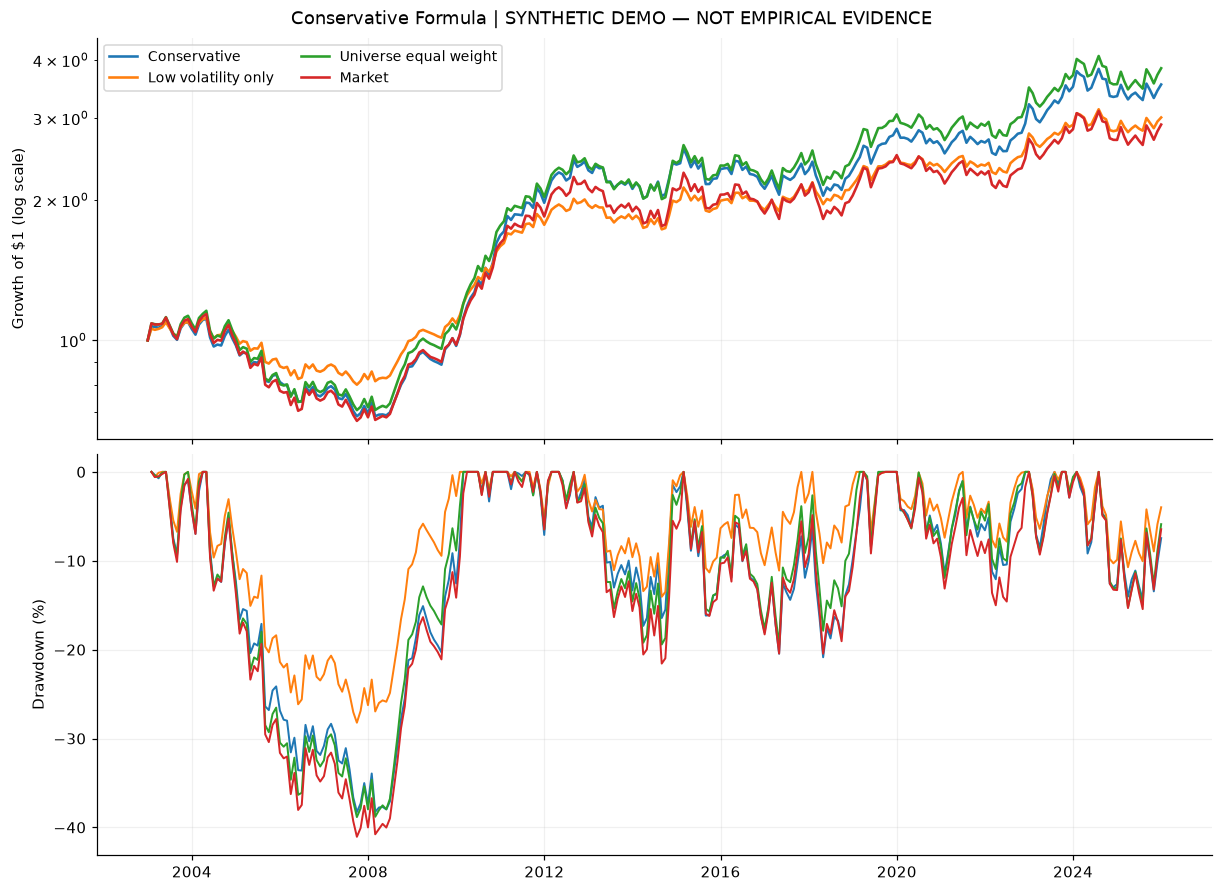

In [7]:
def drawdown(r):
    wealth = (1+r).cumprod()
    return wealth/wealth.cummax().clip(lower=1)-1

def performance(r, rf):
    r = r.dropna()
    excess = r-rf.reindex(r.index)
    assert excess.notna().all()
    std = excess.std(ddof=1)
    return pd.Series({"Months": len(r), "CAGR": np.prod(1+r)**(12/len(r))-1,
        "Ann. volatility": r.std(ddof=1)*np.sqrt(12),
        "Sharpe": excess.mean()/std*np.sqrt(12) if std > 0 else np.nan,
        "Max drawdown": drawdown(r).min(), "Positive months": r.gt(0).mean()})

summary = pd.DataFrame({name: performance(returns[name], benchmark.rf) for name in returns}).T
summary["Ann. one-way turnover"] = pd.Series({name: run.one_way_turnover.mean()*12 for name,run in runs.items()})
display(Markdown(f"### Performance table — {LABEL}"))
display(summary.round(4))

shown = ["Conservative", "Low volatility only", "Universe equal weight", "Market"]
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, layout="constrained")
for name in shown:
    wealth = (1+returns[name]).cumprod()
    wealth = pd.concat([pd.Series([1.], index=[returns.index[0]-pd.offsets.MonthEnd(1)]), wealth])
    axes[0].plot(wealth.index, wealth, label=name, lw=1.7)
    axes[1].plot(returns.index, drawdown(returns[name])*100, label=name, lw=1.3)
axes[0].set_yscale("log")
axes[0].set_ylabel("Growth of $1 (log scale)")
axes[0].legend(ncol=2, fontsize=9)
axes[1].set_ylabel("Drawdown (%)")
fig.suptitle(f"Conservative Formula | {LABEL}", fontsize=12)
fig.savefig(OUT / "wealth_and_drawdown.png", dpi=150)
plt.show()

## 9. Extension A — what does each signal contribute?
Compare the full formula with the same portfolio size and rebalancing frequency after dropping one component. These are
controlled comparisons, not independent discoveries. A change in Sharpe alone is insufficient: check CAGR, drawdown, turnover,
and exposure changes. The low-volatility-only portfolio provides an additional simple reference.

The demo generator assigns no calibrated economic premium to these signals. Its relative performance is a property of artificial
data and random sampling, not an estimate of the value of momentum or payouts in US equities.

### Signal comparisons — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

,Months,CAGR,Ann. volatility,Sharpe,Max drawdown,Positive months,Ann. one-way turnover,CAGR minus full
Conservative,276.0,0.0566,0.1361,0.3405,-0.3828,0.5507,1.5660,0.0000
No momentum,276.0,0.0525,0.1348,0.3141,-0.4008,0.5399,1.1687,-0.0040
No payout,276.0,0.0577,0.1345,0.3511,-0.3487,0.5580,1.7750,0.0012
No low-vol screen,276.0,0.0557,0.1446,0.3234,-0.3874,0.5471,1.8379,-0.0008
Low volatility only,276.0,0.0491,0.0999,0.3503,-0.2822,0.5580,0.4364,-0.0075


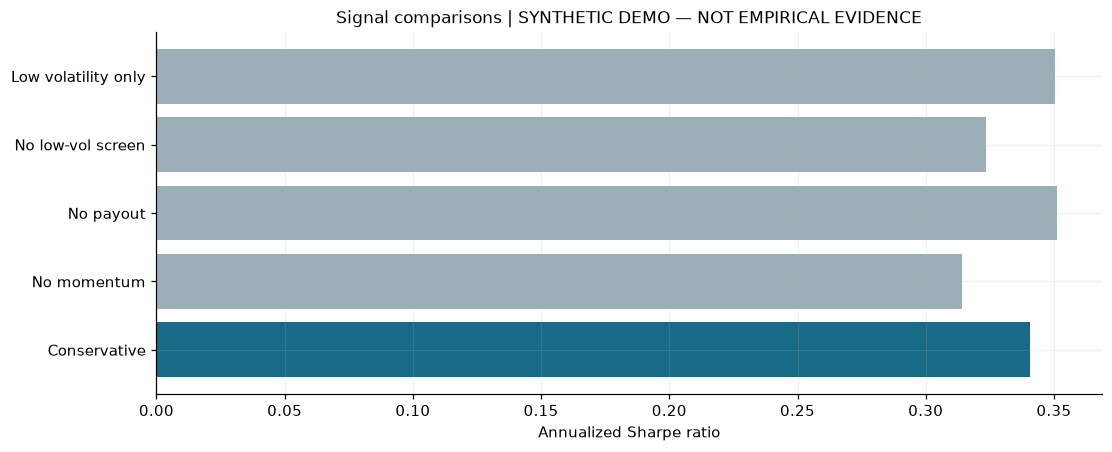

In [8]:
ablation_names = STRATEGIES[:5]
ablation = summary.loc[ablation_names].copy()
ablation["CAGR minus full"] = ablation.CAGR-summary.loc["Conservative", "CAGR"]
display(Markdown(f"### Signal comparisons — {LABEL}"))
display(ablation.round(4))
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.barh(ablation_names, ablation.Sharpe, color=["#176B87"]+["#9CAFB7"]*4)
ax.set_xlabel("Annualized Sharpe ratio")
ax.set_title(f"Signal comparisons | {LABEL}", fontsize=11)
fig.savefig(OUT / "signal_comparisons.png", dpi=150)
plt.show()

## 10. Extension B — performance through time
The intended empirical split is the original sample through December 2016, a separate 2017–2018 transition period, and a
post-publication evaluation from January 2019. January 2019 is chosen to exclude the 2018 publication year; it is not selected from
the returns. Use fixed rules across all periods. A historical post-publication sample is not a prospective untouched holdout for a
researcher working in 2026, so avoid overstating its independence.

The demonstration has only 2003 onward investable returns and cannot cover the original 1929–2016 sample.
Subperiod rows are reported only when at least 12 monthly observations exist, with actual coverage displayed.

In [9]:
periods = {"Through 2016": ("1929-01-01", "2016-12-31"),
           "Transition 2017–2018": ("2017-01-01", "2018-12-31"),
           "Post-publication 2019+": ("2019-01-01", "2099-12-31")}
period_rows = []
for period, (lo, hi) in periods.items():
    for name in ["Conservative", "Market", "Low volatility only"]:
        r = returns.loc[lo:hi, name]
        if len(r) >= 12:
            row = performance(r, benchmark.rf).to_dict()
            period_rows.append({"period": period, "portfolio": name,
                "actual_start": str(r.index.min().date()), "actual_end": str(r.index.max().date()), **row})
subperiods = pd.DataFrame(period_rows)
display(Markdown(f"### Period analysis — {LABEL}"))
display(subperiods.round(4))

### Period analysis — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

,period,portfolio,actual_start,actual_end,Months,CAGR,Ann. volatility,Sharpe,Max drawdown,Positive months
0,Through 2016,Conservative,2003-01-31,2016-12-31,168.0,0.0550,0.1403,0.3237,-0.3828,0.5357
1,Through 2016,Market,2003-01-31,2016-12-31,168.0,0.0458,0.1453,0.2573,-0.4106,0.5417
2,Through 2016,Low volatility only,2003-01-31,2016-12-31,168.0,0.0472,0.1024,0.3259,-0.2822,0.5595
3,Transition 2017–2018,Conservative,2017-01-31,2018-12-31,24.0,0.0489,0.1447,0.2750,-0.1552,0.5417
4,Transition 2017–2018,Market,2017-01-31,2018-12-31,24.0,0.0455,0.1543,0.2454,-0.1639,0.5417
5,Transition 2017–2018,Low volatility only,2017-01-31,2018-12-31,24.0,0.0633,0.1032,0.4713,-0.1027,0.5417
6,Post-publication 2019+,Conservative,2019-01-31,2025-12-31,84.0,0.0619,0.1263,0.3964,-0.1432,0.5833
7,Post-publication 2019+,Market,2019-01-31,2025-12-31,84.0,0.0514,0.1319,0.3095,-0.1544,0.5476
8,Post-publication 2019+,Low volatility only,2019-01-31,2025-12-31,84.0,0.0489,0.0949,0.3616,-0.1073,0.5595


## 11. Extension C — implementation costs
Use 0, 10, 25, and 50 basis points per dollar traded as **illustrative scenarios**, not measured historical costs.
The same positions are used in every scenario; no parameters are tuned to rescue the strategy.
The analysis omits taxes, financing, and nonlinear price impact. Since the strategy is long-only, stock-borrow fees are not modeled.

### Cost sensitivity — SYNTHETIC DEMO — NOT EMPIRICAL EVIDENCE

,Ann. cost approximation,Months,CAGR,Ann. volatility,Sharpe,Max drawdown,Positive months
bps per dollar traded,,,,,,,
0,0.0000,276.0,0.0599,0.1363,0.3633,-0.3764,0.5507
10,0.0031,276.0,0.0566,0.1361,0.3405,-0.3828,0.5507
25,0.0078,276.0,0.0516,0.1358,0.3062,-0.3934,0.5471
50,0.0157,276.0,0.0434,0.1354,0.2485,-0.4153,0.5435


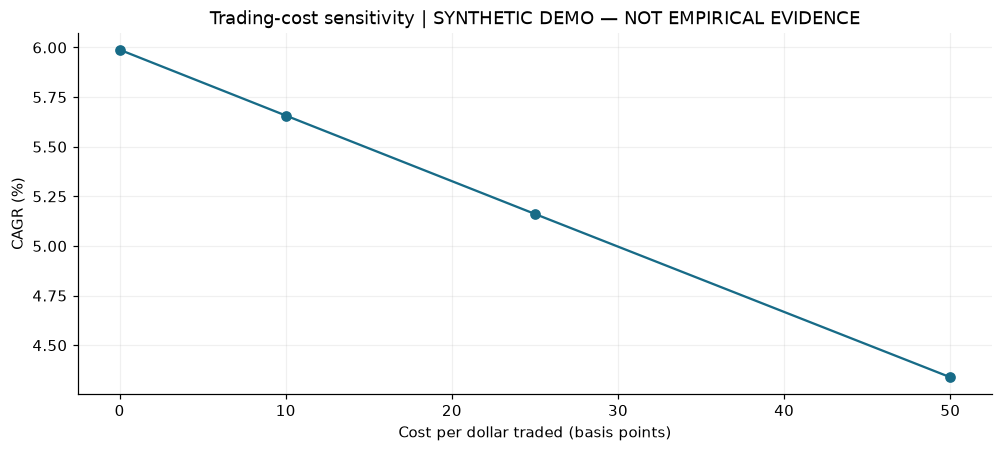

In [10]:
cost_rows = []
for bps in [0, 10, 25, 50]:
    run = backtest(panel, benchmark, targets["Conservative"], START, bps)
    row = performance(run.net, benchmark.rf).to_dict()
    cost_rows.append({"bps per dollar traded": bps,
                      "Ann. cost approximation": run.cost_fraction.mean()*12, **row})
cost_table = pd.DataFrame(cost_rows).set_index("bps per dollar traded")
display(Markdown(f"### Cost sensitivity — {LABEL}"))
display(cost_table.round(4))
assert cost_table.CAGR.is_monotonic_decreasing
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.plot(cost_table.index, cost_table.CAGR*100, marker="o", color="#176B87")
ax.set(xlabel="Cost per dollar traded (basis points)", ylabel="CAGR (%)",
       title=f"Trading-cost sensitivity | {LABEL}")
fig.savefig(OUT / "cost_sensitivity.png", dpi=150)
plt.show()

## 12. Draft interpretation and limitations
**What is established now:** the notebook provides a reproducible selection rule, quarterly targets, monthly portfolio accounting,
weight drift, cash settlement handling, diagnostic tables, and a fixed set of comparisons. The tests check several consequential
implementation errors. The saved demo results establish only that this pipeline executes.

**What is not established:** whether the strategy outperforms, whether the published results can be reproduced, whether its alpha
survives factor controls, or whether it remains practical after real trading frictions. No empirical conclusion can be drawn from
the synthetic charts. The demo is a fixed-universe simulation; terminal-event accounting is tested separately with a toy example.

When real data are available, the discussion should answer:
1. How closely do the sample, signal conventions, gross returns, volatility, and drawdowns match the paper?
2. Does the full formula beat equal-weight and capitalization-weight universe controls, or is weighting driving the result?
3. Which omitted signal changes outcomes most, and is the result stable after costs and in later periods?
4. Are the findings concentrated in certain sectors, stock sizes, or unusually favorable decades?
5. Which discrepancies reflect database revisions, historical eligibility, terminal events, payout definitions, or implementation?

**Inference remains future work.** For the empirical draft, estimate market beta and factor-model alpha using aligned factor data
and heteroskedasticity/autocorrelation-robust standard errors. A paired block bootstrap can quantify uncertainty in strategy
differences while preserving serial dependence. Do not report a positive average return or a higher sample Sharpe as statistical
significance. Multiple extensions increase the chance of finding a favorable result by luck.

### First-draft conclusion
The Conservative Formula is a tractable research topic because its economic story maps to transparent portfolio rules and
testable component comparisons. This draft implements that research design. The central investment question remains unanswered
pending an audited historical equity dataset and reconciliation of the payout construction. The empirical version should preserve
these baseline rules, disclose deviations, and report unfavorable findings as carefully as favorable ones.

## 13. Export results and next submission milestones
Exports carry the mode in both their folder and filenames. The notebook is self-contained in demo mode; its generator and the
executed outputs can be archived with it. For the final course submission, include the actual required data and any helper files
so the notebook can run from beginning to end in the approved environment.

**Before an empirical first submission**
- Confirm Project 8 availability and the team roster under the course's first-come-first-served policy.
- Obtain the instructor's CRSP example and audit the normalization against several stocks, a split, an issuance, and a delisting.
- Confirm the payout proxy, stock/company universe convention, pre-1929 warm-up, and benchmark mapping.
- Replace demo inputs, rerun all cells, investigate failures rather than bypassing them, and replace the draft discussion with actual findings.
- Add factor attribution and uncertainty estimates if time permits. A sector-constraint extension is optional and should follow a clean baseline.

The final deliverable should distinguish replication results from extensions and explain every departure from the paper.

In [11]:
prefix = "synthetic_demo" if MODE == "demo" else "crsp_draft"
summary.to_csv(OUT / f"{prefix}_performance.csv")
returns.to_csv(OUT / f"{prefix}_monthly_returns.csv")
audit_table.to_csv(OUT / f"{prefix}_formation_audit.csv", index=False)
subperiods.to_csv(OUT / f"{prefix}_subperiods.csv", index=False)
cost_table.to_csv(OUT / f"{prefix}_cost_sensitivity.csv")
manifest = {"mode": MODE, "label": LABEL, "seed": SEED if MODE == "demo" else None,
    "universe_cap": N_UNIVERSE, "holdings": N_HOLDINGS, "cost_bps": COST_BPS,
    "first_return": str(returns.index.min().date()), "last_return": str(returns.index.max().date()),
    "payout_definition": "Trailing 12m cash dividend yield + 1 - shares / trailing 24m mean shares",
    "status": "Demonstration only" if MODE == "demo" else "Normalized CRSP input; draft conventions require audit",
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__}
(OUT / f"{prefix}_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"Saved {prefix} tables, charts, and manifest to {OUT}")
print("No real equity performance has been established." if MODE == "demo" else
      "Review provenance and replication deviations before drawing conclusions.")

Saved synthetic_demo tables, charts, and manifest to C:\Users\user\Documents\ChatGPT\MTH9897\final_project\output\demo
No real equity performance has been established.


## References and source notes
1. Van Vliet, P., and Blitz, D. (2018). *The Conservative Formula: Quantitative Investing Made Easy*.
   [SSRN working-paper record](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3145152).
   The working-paper and journal versions use different author ordering. Use a single version consistently in the final bibliography.
2. Robeco (2023). *The Introductory Guide to Conservative Investing*.
   [Guide and further reading](https://www.robeco.com/docm/docu-202302-guide-to-conservative-investing.pdf).
   This provides accessible context and references on low-risk investing; it is also a manager publication, not independent validation.
3. CRSP. *Summary of CIZ Differences to Legacy Files*.
   [Database methodology](https://www.crsp.org/wp-content/uploads/guides/CRSP_US_Stock_%26_Indexes_Databases_Summary_of_CIZ_Differences_to_Legacy_Files.pdf).
   Record the database version actually used in the empirical study.
4. MTH 9897. *Final Projects 2026*, provided course brief, pages 1 and 5: submission requirements and Project 8.

**Further literature to read, not results replicated here:** the paper's references on the low-volatility effect, momentum, and
shareholder payouts are natural starting points for expanding the literature review. Read the originals before attributing specific
mechanisms or numerical findings to them.

**Reproducibility note:** demonstration data are generated by `make_demo` using the fixed seed above. They are artificial and not
derived from CRSP. No live trading, external submission, or upload occurs when running this notebook.